In [1]:
# setting root at top

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# NormModel 64x64 Image and 4 Conv Blocks
# Using OverSampled high-alert and 0.0075 Learning Rate

### Import libraries
* `torch`
* `datasets` and `transforms` from `torchvision` for data Loading.
* `DataLoader` and `WeightedRandomSampler` from `torch.utils.data` for Batching and using data in model.
* `NormModel` from `architectures.NormModel.py`
* `pandas` as `pd`
* `matplotlib.pyplot` as `plt`
* `seaborn` as sns
* `trainer` from `modules.TrainTest`
* `oversampler` from `modules.OverSampler`

In [2]:
# training and architecture
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from architectures.NormModel import NormModel

# visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#trainer and tester modules
from modules.TrainTest import trainer
from modules.OverSampler import oversampler

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [3]:
train_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

train_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/train",
    transform=train_transform
)

sampler = oversampler(
    dataset=train_dataset,
    oversample_rate= 8
)


In [4]:

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Load datasets for training
* load 64x64 images
* load from `../dataset/final-dataset/train`
* convert to tensor
* make batch_size = 32

In [5]:
valid_transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor()
    ]
)

valid_dataset = datasets.ImageFolder(
    root="../dataset/final-dataset/valid",
    transform=valid_transform
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Use Model for training
Initialize model using 
* `conv_layers = 4`, 
* `initial_output_channel = 8` 
* `initial_image_size = 64`

In [6]:
model = NormModel(conv_layers=4, initial_output_channel=8, initial_image_size=64).to("cuda")

In [7]:
metrics = trainer(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=valid_dataloader,
    epoch=100,
    lr=0.0075,
    print_on=10,
    save_dir="../models/norm_img64_c4_lr_0.0075_os/",
    save_checkpoints=10,
    checkpoint_name="norm_64x64_train_0_"
)

Epoch 10/100 | Train Loss: 0.7200 | Validation Loss: 0.7541
Epoch 20/100 | Train Loss: 0.6184 | Validation Loss: 0.8354
Epoch 30/100 | Train Loss: 0.5438 | Validation Loss: 0.8350
Epoch 40/100 | Train Loss: 0.4976 | Validation Loss: 0.8826
Epoch 50/100 | Train Loss: 0.4617 | Validation Loss: 1.0332
Epoch 60/100 | Train Loss: 0.4199 | Validation Loss: 0.7072
Epoch 70/100 | Train Loss: 0.4022 | Validation Loss: 0.6788
Epoch 80/100 | Train Loss: 0.3847 | Validation Loss: 0.6983
Epoch 90/100 | Train Loss: 0.3598 | Validation Loss: 0.8010
Epoch 100/100 | Train Loss: 0.3560 | Validation Loss: 0.6814


## Visualize

Convert metrics to a pd.DataFrame and add epoch column for visualization.

In [8]:
metrics = pd.DataFrame(metrics)
epochs = [i+1 for i  in range(len(metrics))]
metrics["epoch"] = epochs

In [11]:
metrics.iloc[15:45]

,epoch,training_loss,training_accuracy,training_precision,training_recall,training_f1,test_loss,test_accuracy,test_precision,test_recall,test_f1
15,16,0.657298,0.697541,0.652001,0.537227,0.556586,0.670227,0.693774,0.627663,0.494728,0.484111
16,17,0.642340,0.703552,0.650773,0.540279,0.558618,0.709459,0.663278,0.458568,0.480295,0.456280
17,18,0.640831,0.708288,0.683448,0.564419,0.590762,0.685426,0.682762,0.566477,0.554427,0.559634
18,19,0.638475,0.707832,0.664744,0.552602,0.574484,0.677436,0.677255,0.558977,0.511026,0.512545
19,20,0.618402,0.721403,0.686312,0.573973,0.599286,0.835366,0.618806,0.640249,0.497495,0.484511
20,21,0.615682,0.719581,0.693118,0.579760,0.607343,0.649125,0.701398,0.680233,0.512799,0.503548
21,22,0.595052,0.736248,0.717319,0.596164,0.625835,0.659110,0.712834,0.662966,0.513821,0.519189
22,23,0.584315,0.739800,0.716736,0.599745,0.629227,0.684128,0.684456,0.504293,0.495878,0.475838
23,24,0.590600,0.733515,0.717602,0.601612,0.632304,0.707688,0.688691,0.603053,0.483212,0.479129
24,25,0.579674,0.738707,0.723089,0.608857,0.639989,0.762528,0.652690,0.579009,0.486344,0.463642


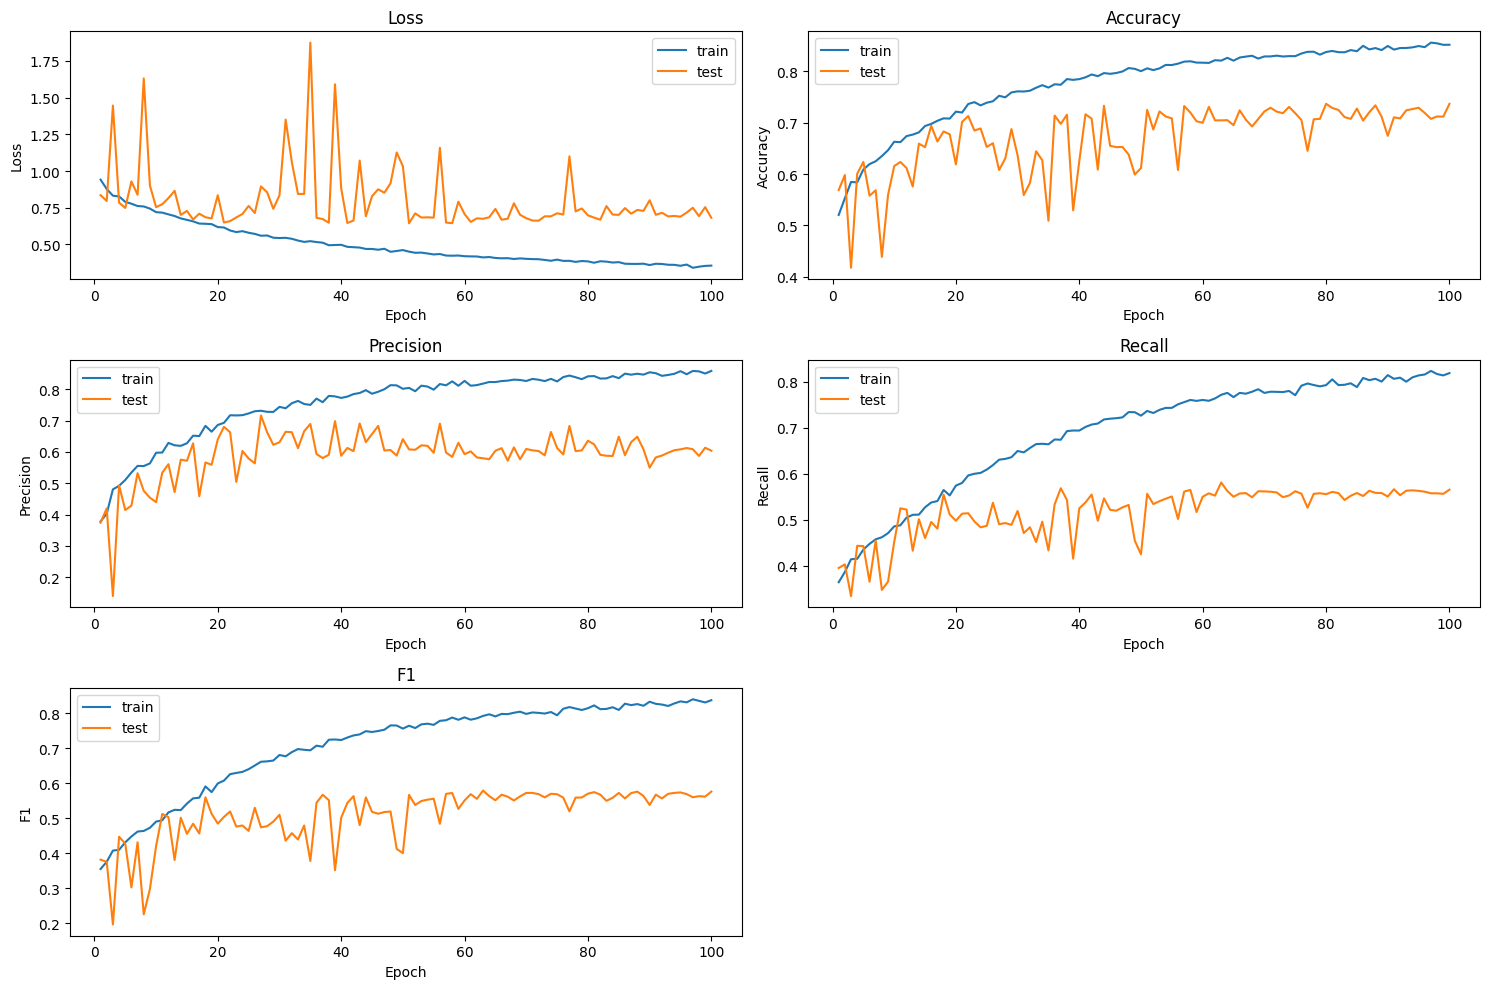

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

to_viz = [
    "loss",
    "accuracy",
    "precision",
    "recall",
    "f1"
]

for i, metric in enumerate(to_viz):

    ax = axes[i]

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"training_{metric}",
        ax=ax,
        label="train"
    )

    sns.lineplot(
        data=metrics,
        x="epoch",
        y=f"test_{metric}",
        ax=ax,
        label="test"
    )

    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())

# Hide unused subplot (6th slot)
axes[-1].axis("off")

plt.tight_layout()
plt.show()